In [1]:
# https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-ovarian-cancer
# https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_xenium.html
# https://colab.research.google.com/github/10XGenomics/analysis_guides/blob/main/Xenium_5k_data_analysis_journey_python.ipynb#scrollTo=ca7d0356

In [2]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as scm
import squidpy as sq
import spatialdata as sd
from spatialdata_io import xenium

import scbiot as scb
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration o

scbiot version 1.1.5


In [3]:
ROOT = Path.cwd()
print(ROOT)
DATA_DIR = ROOT / "inputs" / "xenium"


xenium_dir = DATA_DIR / "Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs"
zarr_path = ROOT / "inputs" / "xenium" / "Xenium_Prime_Ovarian_Cancer.zarr"
rna_h5 = DATA_DIR / "reference" / "17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5"
cell_type = DATA_DIR / "reference" / "FLEX_Ovarian_Barcode_Cluster_Annotation.csv"

# sdata = xenium(xenium_dir,
#                transcripts=False,      # <-- key
#                cells_as_circles=True  # to silence the deprecation warning)               
#             )
# # Convert to Zarr.
# sdata.write(zarr_path, overwrite=True)

/home/figo/software/python_libs/scbiot/examples


In [4]:
rna_h5


PosixPath('/home/figo/software/python_libs/scbiot/examples/inputs/xenium/reference/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5')

In [5]:
sdata = sd.read_zarr(zarr_path)
sdata

SpatialData object, with associated Zarr store: /home/figo/software/python_libs/scbiot/examples/inputs/xenium/Xenium_Prime_Ovarian_Cancer.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 37631, 54089), (4, 18815, 27044), (4, 9407, 13522), (4, 4703, 6761), (4, 2351, 3380)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (37631, 54089), (18815, 27044), (9407, 13522), (4703, 6761), (2351, 3380)
│     └── 'nucleus_labels': DataTree[yx] (37631, 54089), (18815, 27044), (9407, 13522), (4703, 6761), (2351, 3380)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (407124, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (407124, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (401404, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (407124, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), cell_boundaries (Shapes), cell_circles (Shapes), nucle

In [6]:
# For the analysis we use the anndata.AnnData object
adata_query = sdata.tables["table"]
adata_query

AnnData object with n_obs × n_vars = 407124 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

## Calculate quality control metrics

In [7]:
sc.pp.calculate_qc_metrics(adata_query, percent_top=(10, 20, 50, 150), inplace=True)

In [8]:
### The percentage of control probes and control codewords can be calculated from adata.obs

In [9]:
cprobes = (
    adata_query.obs["control_probe_counts"].sum() / adata_query.obs["total_counts"].sum() * 100
)
cwords = (
    adata_query.obs["control_codeword_counts"].sum() / adata_query.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.00075974271899767
Negative decoding count % : 0.0003784626894388888


In [10]:
### Next we plot the distribution of total transcripts per cell, unique transcripts per cell, area of segmented cells and the ratio of nuclei area to their cells

<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

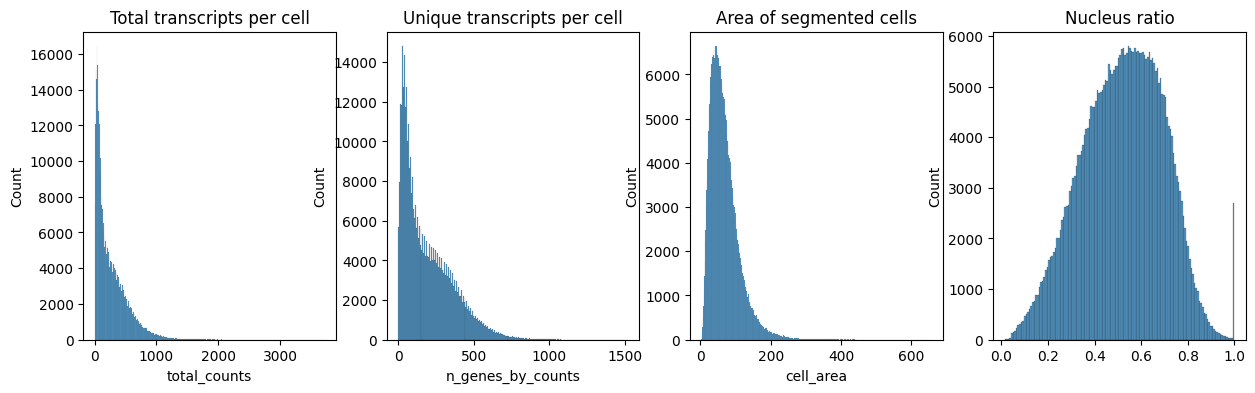

In [11]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata_query.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata_query.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata_query.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata_query.obs["nucleus_area"] / adata_query.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

In [12]:
adata_query.layers["counts"] = adata_query.X.copy()

sc.pp.filter_cells(adata_query, min_counts=20)
thres = np.quantile(adata_query.obs["total_counts"], 0.98)
print(thres)
sc.pp.filter_cells(adata_query, max_counts=thres)

# # We also filter out genes that are rarely expressed
sc.pp.filter_genes(adata_query, min_cells=100)

975.0


## Load scRNA-seq reference

In [13]:
ref = sc.read_10x_h5(rna_h5)
print(ref)

df_celltype = pd.read_csv(cell_type)
print(df_celltype.head())

barcode_col = "Barcode"      
celltype_col = "Cell Annotation"   
# -----------------------------------------------

ref_barcodes = ref.obs_names.astype(str)
csv_barcodes = df_celltype[barcode_col].astype(str)

# build a mapping barcode -> cell_type
mapping = (
    df_celltype.assign(_bc=csv_barcodes)[["_bc", celltype_col]]
    .drop_duplicates("_bc")
    .set_index("_bc")[celltype_col]
)

# assign into ref.obs
ref.obs["cell_type"] = pd.Series(ref_barcodes, index=ref.obs_names).map(mapping)

# remove NA
# remove cells with missing cell_type
adata_ref = ref[ref.obs["cell_type"].notna()].copy()

# quick sanity check
print(ref.obs["cell_type"].value_counts(dropna=False).head(20))
print("Missing cell_type:", ref.obs["cell_type"].isna().sum(), "of", ref.n_obs)

AnnData object with n_obs × n_vars = 17553 × 18082
    var: 'gene_ids', 'feature_types', 'genome'
                      Barcode                 Cell Annotation
0  AAACAAGCAAAGGTAAACTTTAGG-1    Tumor Associated Fibroblasts
1  AAACAAGCAAATCACGACTTTAGG-1               Endothelial Cells
2  AAACAAGCAACTTGTCACTTTAGG-1  Stromal Associated Fibroblasts
3  AAACAAGCAAGGCCTGACTTTAGG-1    Tumor Associated Fibroblasts
4  AAACAAGCACATTCGTACTTTAGG-1    Tumor Associated Fibroblasts
cell_type
Macrophages                       2327
Tumor Cells                       2255
Tumor Associated Fibroblasts      2251
Proliferative Tumor Cells         1950
Stromal Associated Fibroblasts    1375
Endothelial Cells                 1353
VEGFA+ Tumor Cells                1325
Smooth Muscle Cells                959
Pericytes                          881
T & NK Cells                       812
MT-High, Jun+/Fos+ Tumor Cells     606
NaN                                503
Fallopian Tube Epithelium          298
Granulosa Cel

In [14]:
# frac = 0.2
# rng = np.random.default_rng(0)

# n = int(np.floor(frac * adata_query.n_obs))
# idx = rng.choice(adata_query.n_obs, size=n, replace=False)
# adata_query = adata_query[idx, :].copy()
# adata_query

In [15]:
# Fix duplicated gene symbols
adata_query.layers['counts'] = adata_query.X.copy()
adata_ref.layers['counts'] = adata_ref.X.copy()
adata_ref.var["gene_symbol"] = adata_ref.var_names  # make it a var column

adata_ref = sc.get.aggregate(
    adata_ref,
    by="gene_symbol",
    axis="var",        # aggregate features
    func="sum",
    layer="counts",
)
adata_ref.layers['counts'] = adata_ref.layers['sum']
adata_ref.X = adata_ref.layers['sum']
adata_ref

AnnData object with n_obs × n_vars = 17050 × 18079
    obs: 'cell_type'
    var: 'gene_symbol'
    layers: 'sum', 'counts'

In [ ]:
import numpy as np
import scipy.sparse as sp
import scanpy as sc
import anndata
import scbiot as scb

# Strore raw counts
adata_ref.layers["counts"] = adata_ref.X.copy()
adata_query.layers["counts"] = adata_query.X.copy()

adata_ref_umap = adata_ref.copy()

sc.pp.highly_variable_genes(adata_ref_umap, n_top_genes=2000, flavor="seurat_v3")
sc.pp.normalize_total(adata_ref_umap)
sc.pp.log1p(adata_ref_umap)
sc.pp.scale(adata_ref_umap)
sc.tl.pca(adata_ref_umap, n_comps=50, use_highly_variable=True)
sc.pp.neighbors(adata_ref_umap, use_rep="X_pca")
sc.tl.umap(adata_ref_umap)
# sc.pl.umap(adata_ref_umap)

# Generate umap of reference if using reference umap
adata_ref.obsm["X_pca"] = adata_ref_umap.obsm["X_pca"].copy()
adata_ref.obsm["X_umap"] = adata_ref_umap.obsm["X_umap"].copy()

adata_ref.obs["cell_type"] = adata_ref.obs["cell_type"]
adata_query.obs["cell_type"] = "Unknown"

adata = anndata.concat([adata_ref, adata_query], join='inner', label="batch", keys=["reference", "query"])
print(adata)

# Key：store raw counts back
adata.X = adata.layers["counts"].copy()
# print(adata)
counts = adata.layers["counts"].copy()

# add umap to concated adata
# rebuild X_umap on the concatenated adata (ref only)
umap = np.full((adata.n_obs, adata_ref_umap.obsm["X_umap"].shape[1]), np.nan, dtype=float)
ref_mask = (adata.obs["batch"].values == "reference")
umap[ref_mask] = adata_ref_umap.obsm["X_umap"]
adata.obsm["X_umap"] = umap


sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)


adata, metrics = scb.ot.integrate(
    adata,
    preset='anchor',
    obsm_key="X_pca",
    batch_key="batch",    
    out_key="X_supbiot",    
    label_key="cell_type",
    unlabeled_category="Unknown"    
)


AnnData object with n_obs × n_vars = 393657 × 4902
    obs: 'cell_type', 'batch'
    layers: 'counts'
[prealign] CORAL enabled target=auto strength=1.0
[final] mix=0.014 overlap0=0.228 strain=0.25113 tw=0.881


In [17]:
adata = scb.ot.supbiot(
adata,
label_key="cell_type",
unlabeled_category="Unknown",
pred_label_key='pred_cell_type',
pred_conf_key="pred_confidence",
min_conf=0.25
)
adata.layers["counts"] = counts

In [18]:
adata

AnnData object with n_obs × n_vars = 393657 × 4902
    obs: 'cell_type', 'batch', 'pred_cell_type', 'pred_confidence'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', '_ot_alignment', '_supbiot'
    obsm: 'X_umap', 'X_pca', 'X_supbiot'
    varm: 'PCs'
    layers: 'counts'

In [19]:
adata_query = adata[adata.obs['batch'] == 'query'].copy()
adata_ref = adata[adata.obs['batch'] == 'reference'].copy()
adata_query.obs['pred_cell_type'].value_counts()

pred_cell_type
Tumor Cells                       58402
Tumor Associated Fibroblasts      46055
MT-High, Jun+/Fos+ Tumor Cells    42964
Macrophages                       39871
Proliferative Tumor Cells         38397
Smooth Muscle Cells               31237
Stromal Associated Fibroblasts    29710
VEGFA+ Tumor Cells                26787
Endothelial Cells                 21432
Pericytes                         14953
T & NK Cells                      12243
Fallopian Tube Epithelium          4559
Ciliated Epithelial Cells          3893
Granulosa Cells                    2680
Malignant Cells Lining Cyst        2075
Inflammatory Tumor Cells           1349
Name: count, dtype: int64

In [20]:
adata_query

AnnData object with n_obs × n_vars = 376607 × 4902
    obs: 'cell_type', 'batch', 'pred_cell_type', 'pred_confidence'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', '_ot_alignment', '_supbiot'
    obsm: 'X_umap', 'X_pca', 'X_supbiot'
    varm: 'PCs'
    layers: 'counts'

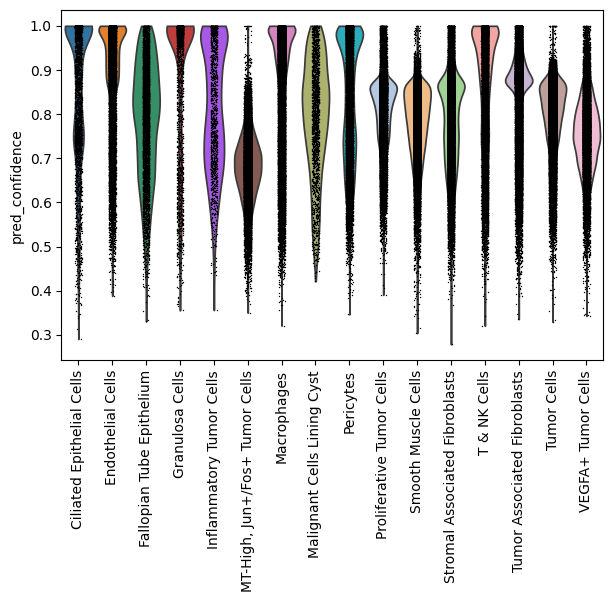

In [21]:
sc.pl.violin(adata_query, keys="pred_confidence", groupby="pred_cell_type", rotation=90)

In [22]:
sc.pp.neighbors(adata, use_rep='X_supbiot', n_neighbors=50, metric="cosine")
sc.tl.umap(adata, min_dist=0.3, spread=1.0, random_state=0)

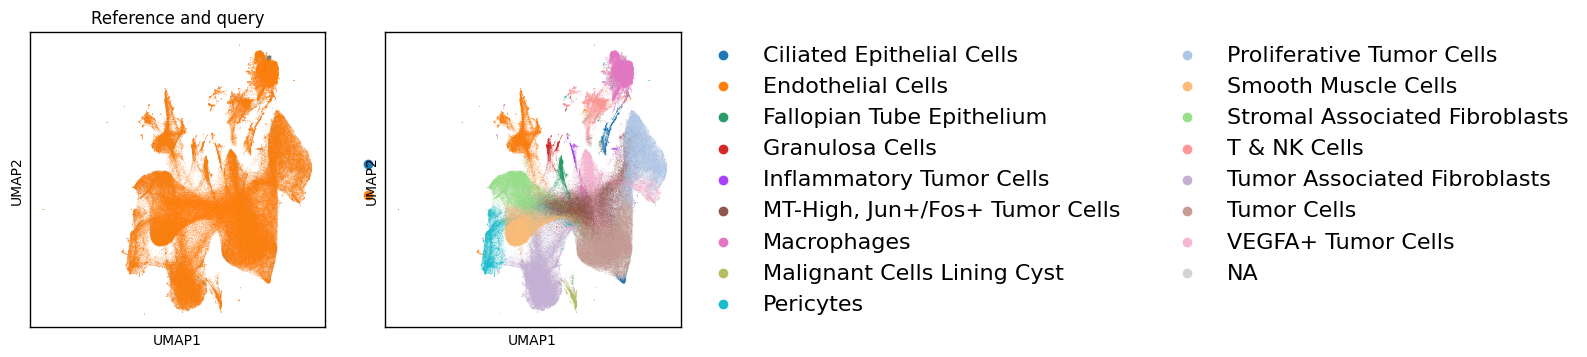

In [23]:
counts = adata_ref.obs['cell_type'].value_counts()
celltype_order = counts.index.tolist()
adata_ref.obs['cell_type'] = adata_ref.obs['cell_type'].astype(
    pd.CategoricalDtype(categories=celltype_order, ordered=True)  # from adata_gex
)

sc.settings._vector_friendly = True

# Make sure the default edge isn’t white or hairline
mpl.rcParams['axes.edgecolor'] = 'black'
mpl.rcParams['axes.linewidth'] = 1.0

def force_border(ax):
    ax.set_axis_on()           # ensure axes are on
    ax.set_frame_on(True)      # ensure frame is drawn
    ax.patch.set_visible(True) # ensure background patch exists
    for side in ax.spines.values():
        side.set_visible(True)
        side.set_color('black')
        side.set_linewidth(1.0)

methods = ["X_supbiot"]

ncols = 2 * len(methods)
fig, axes = plt.subplots(1, ncols, figsize=(4.2*ncols, 4.2), squeeze=False)
axes = axes[0]

for i, method in enumerate(methods):
    basis = f"X_umap_{method}"
    axL, axR = axes[2*i], axes[2*i+1]   

    sc.pl.embedding(
        adata, basis="X_umap", color="batch",
        frameon=True, ax=axL, show=False,
        legend_loc="right margin", legend_fontsize=16, title='Reference and query'
    )
    axL.set_box_aspect(1)
    axL.set_xlabel("UMAP1"); axL.set_ylabel("UMAP2")
    force_border(axL)    

    sc.pl.embedding(
        adata, basis="X_umap", color="pred_cell_type", # "scBIOT_celltype", #"cell_type",
        frameon=True, ax=axR, show=False,
        legend_loc="right margin", legend_fontsize=16, title=""
    )
    axR.set_box_aspect(1)
    axR.set_xlabel("UMAP1"); axR.set_ylabel("UMAP2")
    force_border(axR)

plt.tight_layout()
# fig.savefig(f"{cwd}_batch_and_leiden_per_embedding.pdf", dpi=300, transparent=True)


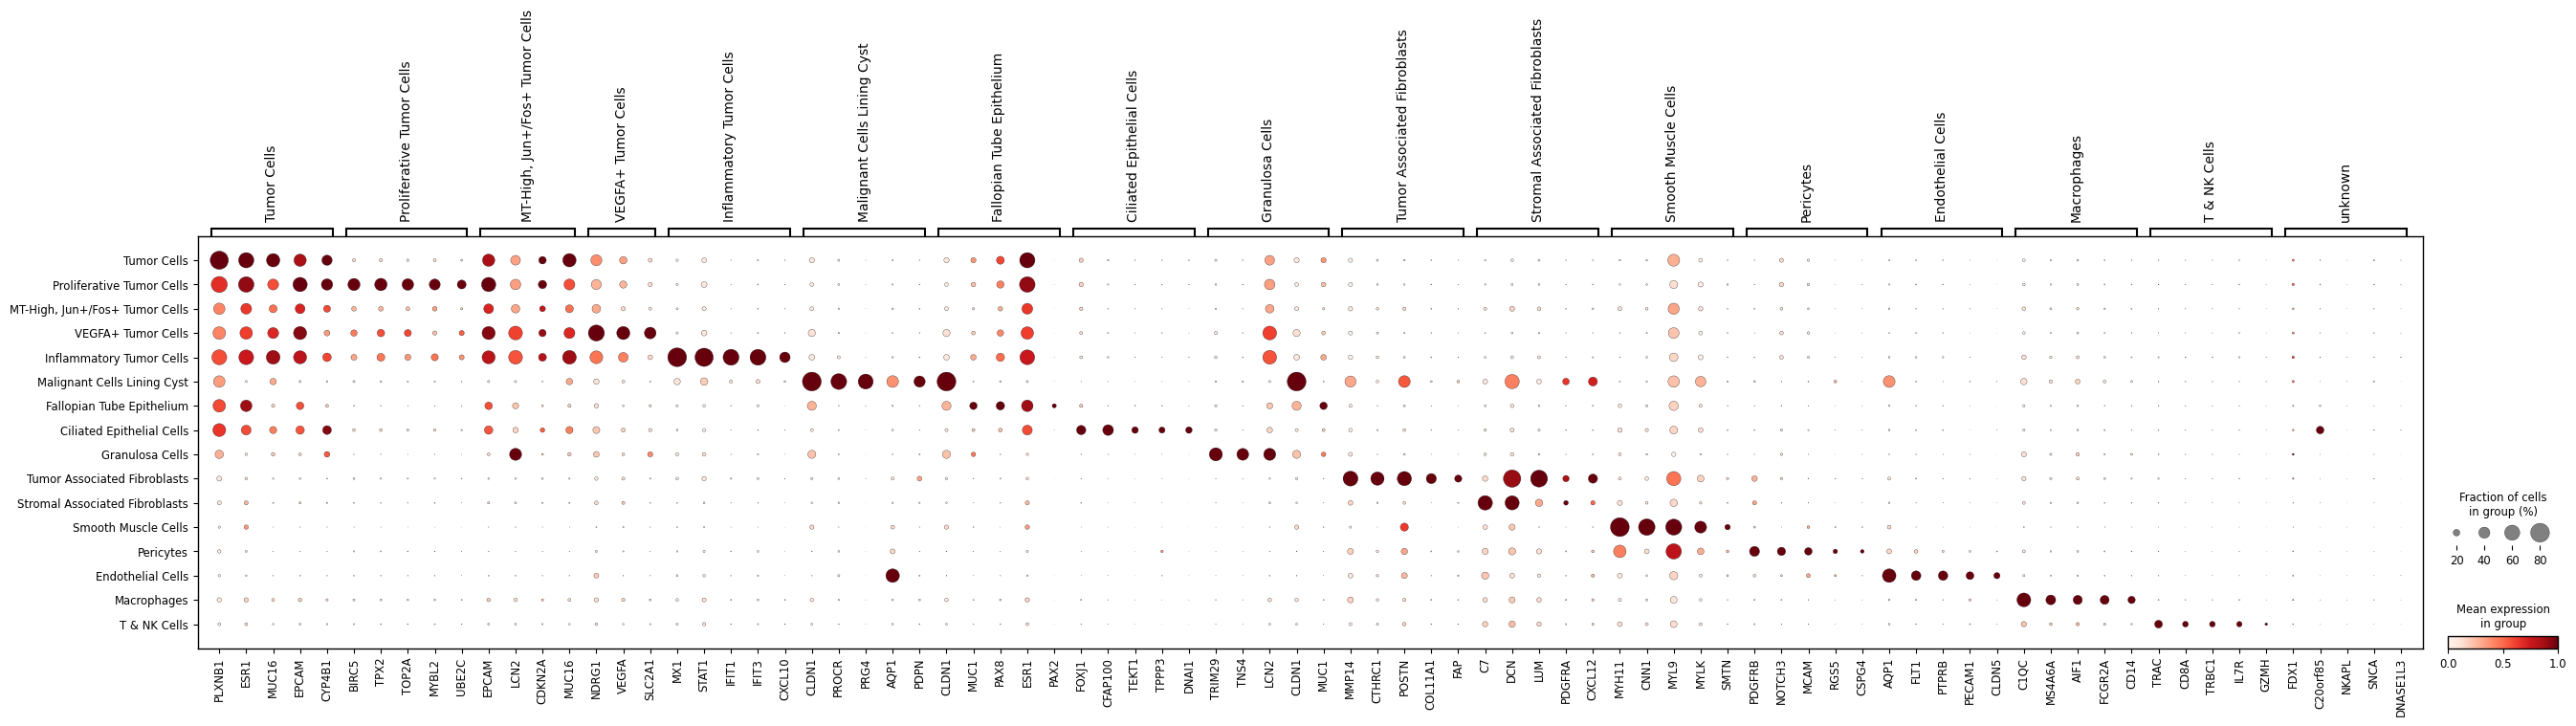

In [24]:
# -----------------------------
order = [
    "Tumor Cells",
    "Proliferative Tumor Cells",
    "MT-High, Jun+/Fos+ Tumor Cells",
    "VEGFA+ Tumor Cells",
    "Inflammatory Tumor Cells",
    "Malignant Cells Lining Cyst",
    "Fallopian Tube Epithelium",
    "Ciliated Epithelial Cells",
    "Granulosa Cells",
    "Tumor Associated Fibroblasts",
    "Stromal Associated Fibroblasts",
    "Smooth Muscle Cells",
    "Pericytes",
    "Endothelial Cells",
    "Macrophages",
    "T & NK Cells",
    "unknown",
]
adata_query.obs["pred_cell_type"] = adata_query.obs["pred_cell_type"].astype("category")
# keep only categories that exist in your data (avoid errors)
order = [ct for ct in order if ct in adata_query.obs["pred_cell_type"].cat.categories]
adata_query.obs["pred_cell_type"] = adata_query.obs["pred_cell_type"].cat.reorder_categories(order, ordered=True)

# -----------------------------
# 2) Marker genes (EDIT ME)
# -----------------------------
# -----------------------------
# 2) Marker genes (UPDATED: <= 5 genes each, from your new DEGs)
# -----------------------------
markers = {
    "Tumor Cells": [
        "PLXNB1", "ESR1", "MUC16", "EPCAM", "CYP4B1"
    ],
    "Proliferative Tumor Cells": [
        "BIRC5", "TPX2", "TOP2A", "MYBL2", "UBE2C"
    ],
    "MT-High, Jun+/Fos+ Tumor Cells": [
        "H19", "EPCAM", "LCN2", "CDKN2A", "MUC16"
    ],
    "VEGFA+ Tumor Cells": [
        "H19", "NDRG1", "VEGFA", "LDHA", "SLC2A1"
    ],
    "Inflammatory Tumor Cells": [
        "MX1", "STAT1", "IFIT1", "IFIT3", "CXCL10"
    ],
    "Malignant Cells Lining Cyst": [
        "CLDN1", "PROCR", "PRG4", "AQP1", "PDPN"
    ],
    "Fallopian Tube Epithelium": [
        "CLDN1", "MUC1", "PAX8", "ESR1", "PAX2"
    ],
    "Ciliated Epithelial Cells": [
        "FOXJ1", "CFAP100", "TEKT1", "TPPP3", "DNAI1"
    ],
    "Granulosa Cells": [
        "TRIM29", "TNS4", "LCN2", "CLDN1", "MUC1"
    ],
    "Tumor Associated Fibroblasts": [
        "MMP14", "CTHRC1", "POSTN", "COL11A1", "FAP"
    ],
    "Stromal Associated Fibroblasts": [
        "C7", "DCN", "LUM", "PDGFRA", "CXCL12"
    ],
    "Smooth Muscle Cells": [
        "MYH11", "CNN1", "MYL9", "MYLK", "SMTN"
    ],
    "Pericytes": [
        "PDGFRB", "NOTCH3", "MCAM", "RGS5", "CSPG4"
    ],
    "Endothelial Cells": [
        "AQP1", "FLT1", "PTPRB", "PECAM1", "CLDN5"
    ],
    "Macrophages": [
        "C1QC", "MS4A6A", "AIF1", "FCGR2A", "CD14"
    ],
    "T & NK Cells": [
        "TRAC", "CD8A", "TRBC1", "IL7R", "GZMH"
    ],
    "unknown": [
        "FDX1", "C20orf85", "NKAPL", "SNCA", "DNASE1L3"
    ],
}

# -----------------------------
# 3) Keep only genes that exist in the object (prevents KeyErrors)
# -----------------------------
present = set(adata_query.var_names)
markers_present = {k: [g for g in v if g in present] for k, v in markers.items()}

# optionally drop empty entries (if none of their markers are present)
markers_present = {k: v for k, v in markers_present.items() if len(v) > 0}

# -----------------------------
# 4) Dotplot
sc.pl.dotplot(
    adata_query,
    var_names=markers_present,
    groupby="pred_cell_type",
    standard_scale="var",
    dot_min=0.0,
    dot_max=0.8,
    show=True,
)


In [ ]:
sc.tl.rank_genes_groups(
    adata_query,
    groupby="pred_cell_type",
    method="wilcoxon",       # robust default
    pts=True,                # adds fraction-expressing metrics (pct)
    use_raw=False            # set True only if adata.raw holds log1p normalized data
)

# Quick visual: top markers per group (ranked genes)
sc.pl.rank_genes_groups(adata_query, n_genes=20, sharey=False)

# ----------------------------
# (A) Get a tidy dataframe for ALL groups (long format)
df_all = sc.get.rank_genes_groups_df(adata_query, group=None)

# Optional filtering: keep "useful" hits (tune thresholds)
df_filt = df_all.query("pvals_adj < 0.05 and logfoldchanges > 0.25").copy()

# Save to disk (edit path)
# df_all.to_csv("DE_cell_type_vs_rest_all.csv", index=False)
# df_filt.to_csv("DE_cell_type_vs_rest_filtered.csv", index=False)

# (B) Save one file per cell type (top 200 by adjusted p-value)
# out = {}
# for ct in adata.obs["pred_cell_type"].cat.categories if pd.api.types.is_categorical_dtype(adata.obs["pred_cell_type"]) else adata.obs["cell_type"].unique():
#     d = df_all[df_all["group"] == ct].copy()
#     d = d.sort_values(["scores", "pvals_adj"]).head(200)
#     out[ct] = d
#     safe = str(ct).replace("/", "_").replace(" ", "_")
#     d.to_csv(f"DE_{safe}_vs_rest_top200.csv", index=False)

# print("Done. Example head:\n", df_filt.head())

In [ ]:
df_all = df_all.sort_values(["group", "scores"], ascending=[True, False])

for g in df_all["group"].unique():
    df_g = df_all[df_all["group"] == g].head(100)

    # Print as one-line list of genes
    genes = df_g["names"].tolist()
    print("\n" + "="*80)
    print(f"pred_cell_type = {g}  |  Top100 genes")
    print(", ".join(genes))

    # Optional: if you prefer a mini table, uncomment:
    # print(df_g[["names", "logfoldchanges", "pvals_adj", "scores", "pct_nz_group", "pct_nz_reference"]].head(15).to_string(index=False))

# ----------------------------
# 3) (Optional) export top100 per cluster to a single CSV
# ----------------------------
top100 = df_all.groupby("group", group_keys=False).head(100)
# top100.to_csv(f"top100_DE_by_{GROUPBY}.csv", index=False)
# print(f"\nSaved: top100_DE_by_{GROUPBY}.csv")
# top100


pred_cell_type = Ciliated Epithelial Cells  |  Top100 genes
CFAP100, FOXJ1, C20orf85, AC007906.2, FAM183A, CDHR4, TEKT1, MLF1, TPPP3, IFT57, RBM38, ERICH3, MAPK15, CFAP47, FAM216B, PLXNB1, IL5RA, HMGN3, DNAI1, EFHC1, CFAP43, LDLRAD1, NEK11, CYP4B1, SPAG8, FHAD1, PTGES3, DRC3, F11R, DZIP1L, DNAH11, MDM2, SPAG17, SERPINI2, RUVBL1, DNAH7, SQLE, JPT2, ODF2L, MAPK10, ZMYND10, DLEC1, DRC1, SPATA18, ALCAM, DNAH10, HIPK3, CCDC50, DNAH9, RFX2, UCHL1, MYCBP, P4HTM, DNAH12, CCDC113, DNAJC10, MYB, CSPP1, EPCAM, UFC1, GCLM, PTPRF, KIAA1324, CFAP46, RAB11FIP1, PPP1R7, UCP2, CDKN1A, GRHL2, SINHCAF, SPAG1, LRBA, NOA1, DNAH5, ESR1, H3F3B, HSF1, BCL2L1, FLNB, SRD5A2, SRI, EVI5, C2orf88, NFE2L2, STK33, CCDC170, WNT9A, CEP19, SDC4, CD46, EFHC2, UGDH, SOD1, DYDC1, PAIP2, NQO1, GPR162, KCNC3, SOST, RMND5A

pred_cell_type = Endothelial Cells  |  Top100 genes
AQP1, PTPRB, SOCS3, EPAS1, FLT1, SLCO2A1, PECAM1, TGFBR2, PLVAP, CD93, SHANK3, EGFL7, CD34, ENG, TIMP3, CLDN5, TMEM255B, EMP1, TIE1, HSPG2, CCL14, CAVI

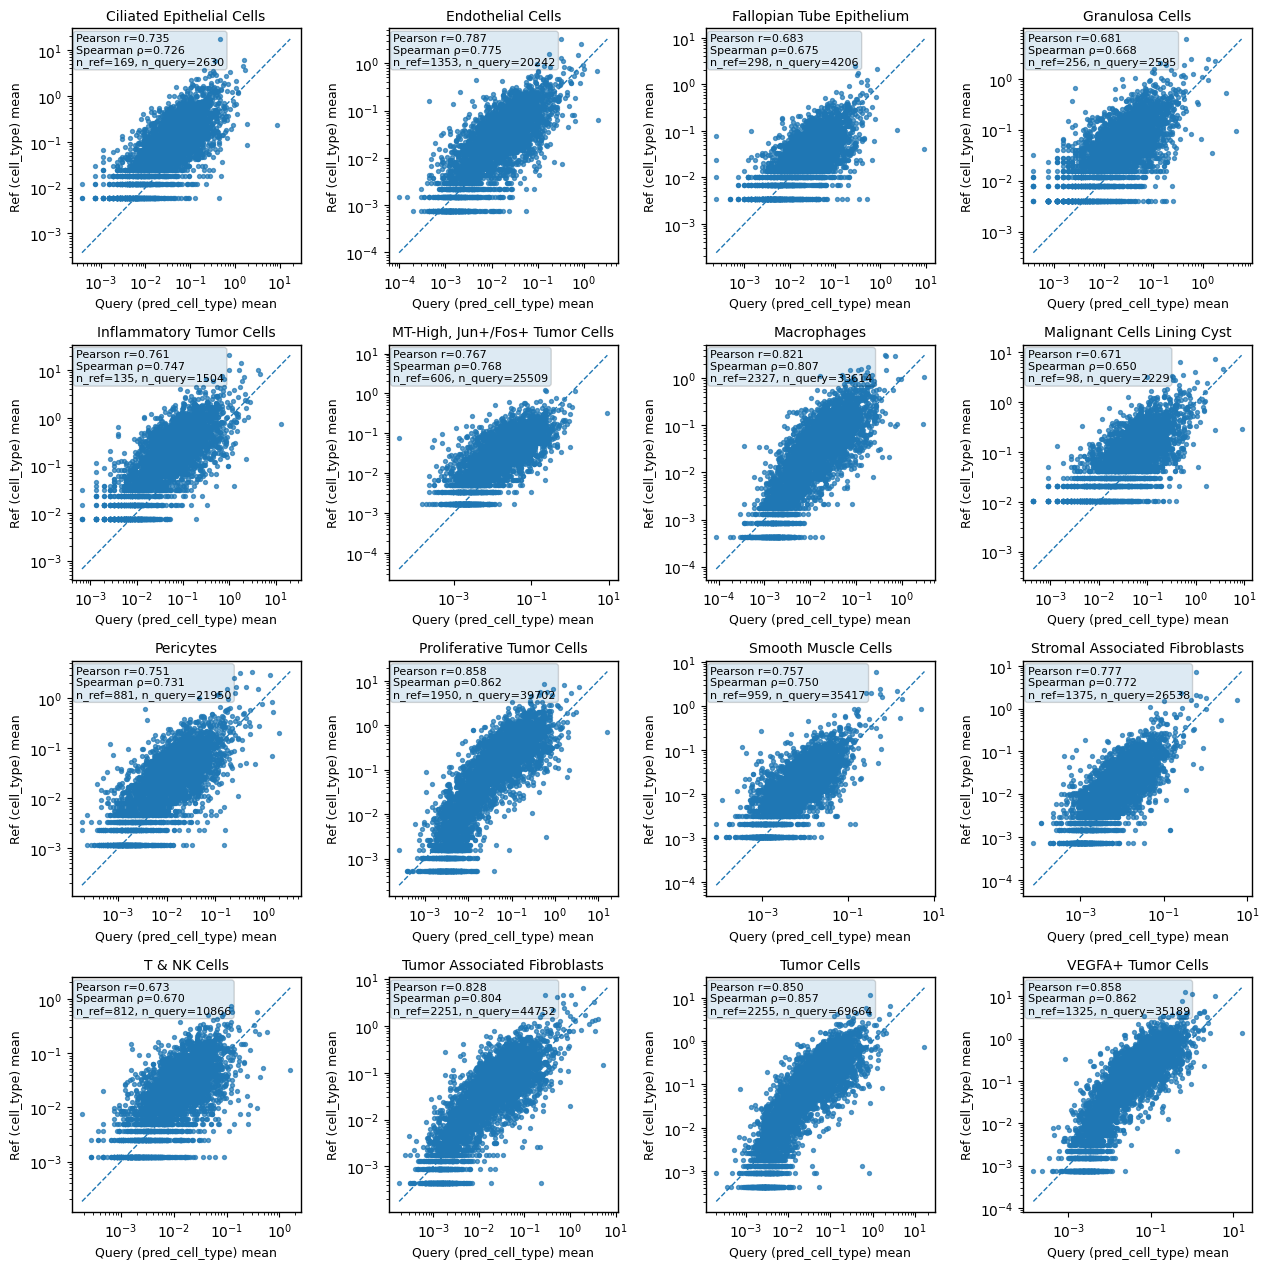

In [ ]:
import scbiot as scb

fig, corr_df, means_ref_df, means_qry_df = scb.pl.celltype_gene_mean_correlation(
    adata_ref,
    adata_query,
    ref_group_key="cell_type",
    query_group_key="pred_cell_type",
    layer="counts",
    use_raw=False,
    min_cells=30,
    ncols=4,
)

# print(corr_df.head(10))
# fig.savefig("celltype_gene_mean_correlations.png", dpi=200, bbox_inches="tight")


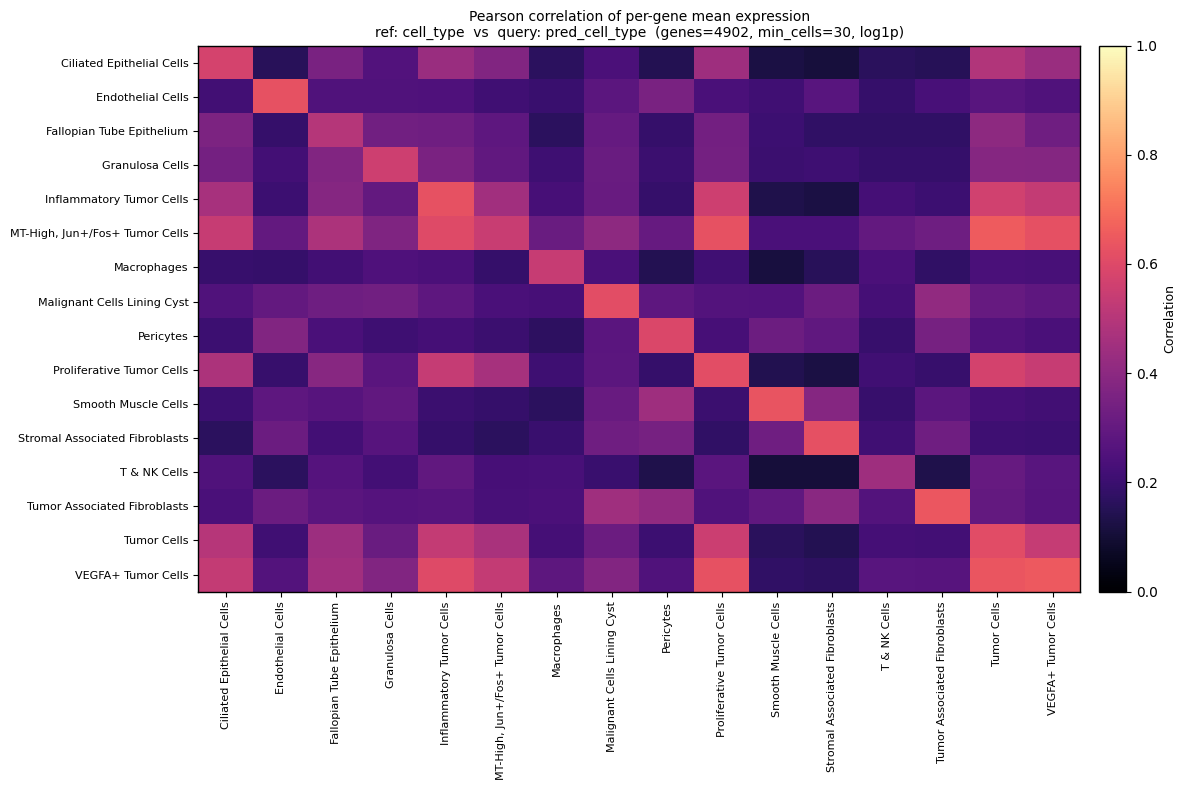

In [ ]:
fig, ax, corr_df, means_ref_df, means_qry_df = scb.pl.celltype_predtype_mean_corr_heatmap(
    adata_ref,
    adata_query,
    ref_group_key="cell_type",
    query_group_key="pred_cell_type",
    layer="counts",
    use_raw=False,
    min_cells=30,
    transform="log1p",
    method="pearson",
    figsize=(12, 8),
    vmin=0.0,
    vmax=1.0,
)

In [ ]:
adata_query.obs['pred_cell_type'].value_counts()

pred_cell_type
Tumor Cells                       69664
Tumor Associated Fibroblasts      44752
Proliferative Tumor Cells         39702
Smooth Muscle Cells               35417
VEGFA+ Tumor Cells                35189
Macrophages                       33614
Stromal Associated Fibroblasts    26538
MT-High, Jun+/Fos+ Tumor Cells    25509
Pericytes                         21950
Endothelial Cells                 20242
T & NK Cells                      10866
Fallopian Tube Epithelium          4206
Ciliated Epithelial Cells          2630
Granulosa Cells                    2595
Malignant Cells Lining Cyst        2229
Inflammatory Tumor Cells           1504
Name: count, dtype: int64